# Using Machine Learning Algorithms to Categorize Particle Jets

# Introduction

### What is a jet?
Put simply, a jet is a stream of particle that are created during particle collisions. The following video of provides a visual explanation of this phenomenon:

https://www.youtube.com/watch?v=FMH3T05G_to

As seen in this video, and the gif below, a proton-proton collision results in the creation of a number of particles due to the separation of quarks. The gluon binding the quarks together "stretches" until the energy added to the system is enough to create a quark-antiquark pair.

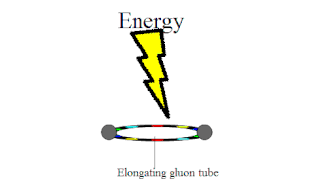

In a high-speed particle collision, this can occur dozens of times, which is what creates a jet. These jets do not have to be created directly by the original collision, and can also be created by other collision products. This results in a "shower" of particles. In particle accelerators like the Large Hadron Collider these particle jets can be detected.

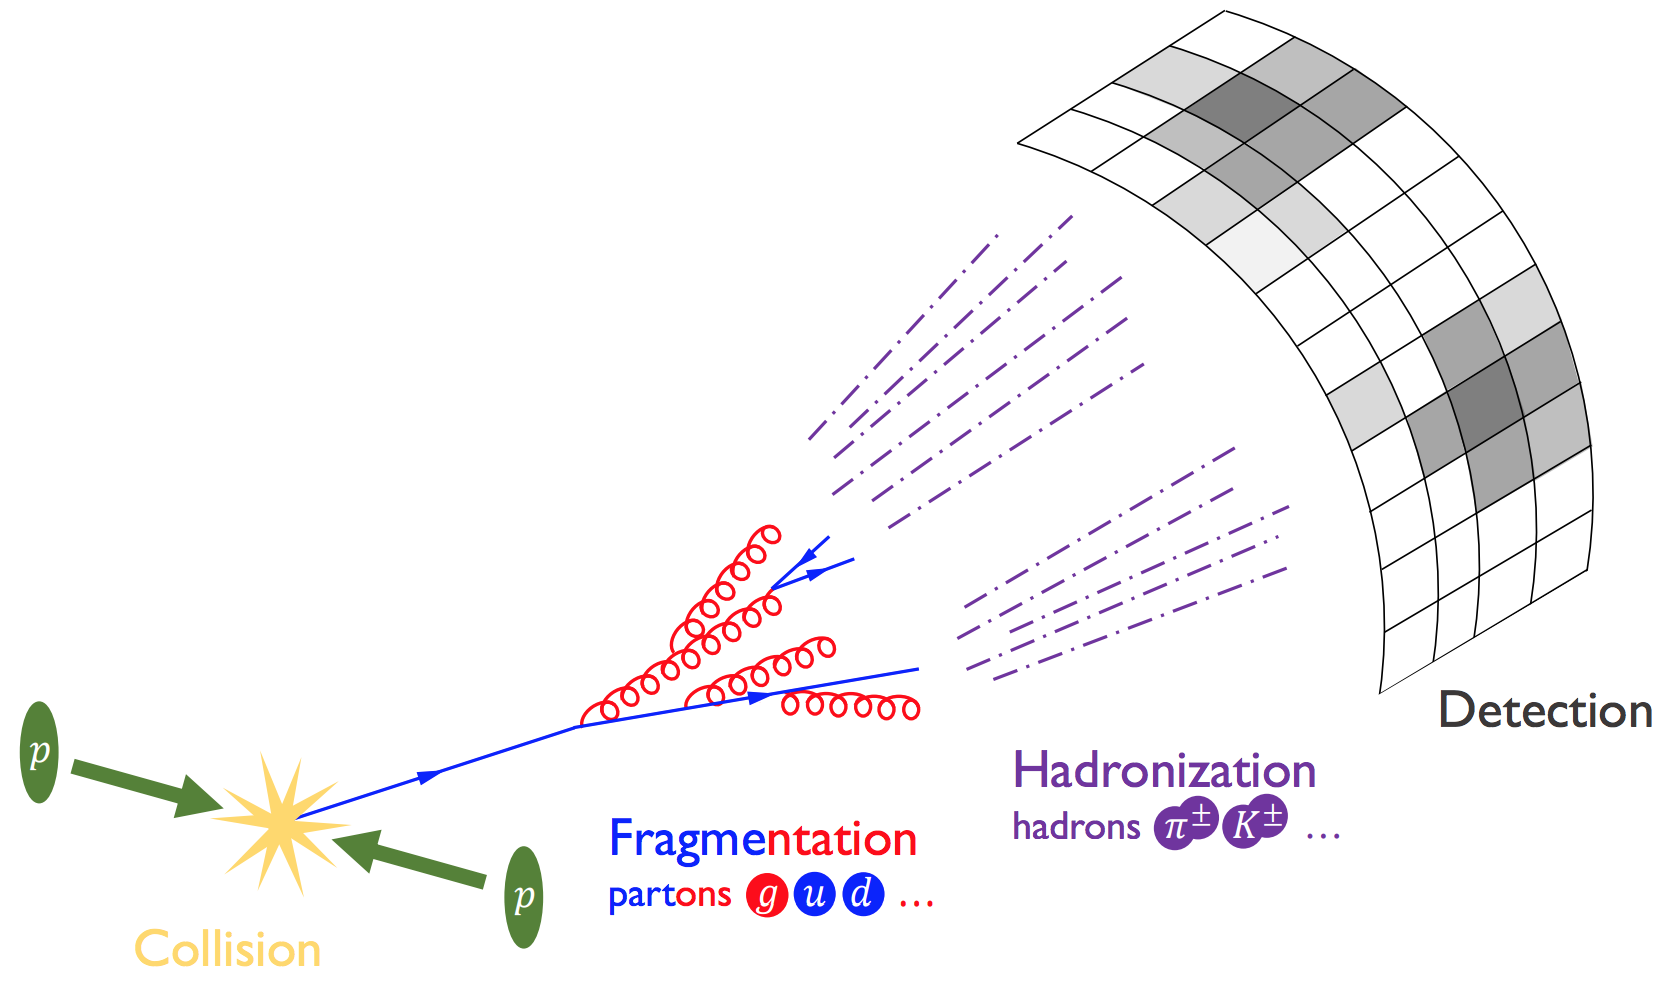

However, determining the particle that these jets originated from is a very complicated and computationally expensive process. Thus, machine learning algorithms have been explored for the purpose of categorizing jets, which is known as jet tagging.

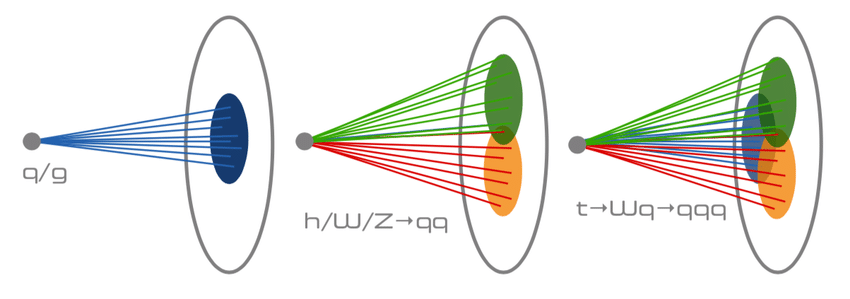

# JetNet
The dataset we used for this project is called JetNet. JetNet is a publicly available dataset, as well as a python package. Its data is not real particle physics experimental data, and is all simulated.

Source of dataset: https://zenodo.org/records/6975118

JetNet package API: https://jetnet.readthedocs.io/en/latest/

JetNet GitHub Page: https://github.com/jet-net/JetNet

### JetNet DataSet

The JetNet dataset contained around 800,000 jets of 5 different types, where each type is the particle that created the jet. The jets are categorized as follows:

Gluon (g) (N = 177252)

Top Quark (t) (N = 177945)

Light Quark (q) (N = 170679)

W boson (w) (N = 177172)

and Z boson (z) (N = 176952)

In [1]:
from jetnet.datasets import JetNet # Package used to download and analyze JetNet data.
from jetnet.utils import jet_features # Package used to calculate jet particle features.

In [2]:
 # Function that creates lists for particle and jet data.
def DataGrabber():

    # Defines a dictionary containing all of the JetNet particle and jet data. Each dictionary entry's name is predefined in the JetNet API.
    Jet_Data = {
        "jet_type": ["g", "t", "q", "w", "z"],
        "data_dir": "datasets/jetnet",
        "particle_features": ["etarel", "phirel", "ptrel"],
        "jet_features": ["type", "num_particles"],
        "download": True
    }
    # Unpacks the dictionary into two lists. .getData() returns particle data, jet data. **Jet_Data means pass the entire dictionary.
    particle_data, jet_data = JetNet.getData(**Jet_Data)

    # Return arrays.
    return particle_data, jet_data

### Jet Data Structure

The JetNet data is contained within a dictionary, consisting of jet_features and particle_features, as well as a few other elements related to initialization/downloading the dataset.

The Coordinate system used to describe a jet and its constituent particles is as follows:

The centre of the jet is taken to be the z-axis

$\eta$: A transformed polar angle, but for all intents and purposes can be thought of as a polar angle

$\phi$: The azimuthal angle

$\rho_T$: Transverse momentum, which is momentum in the xy plane

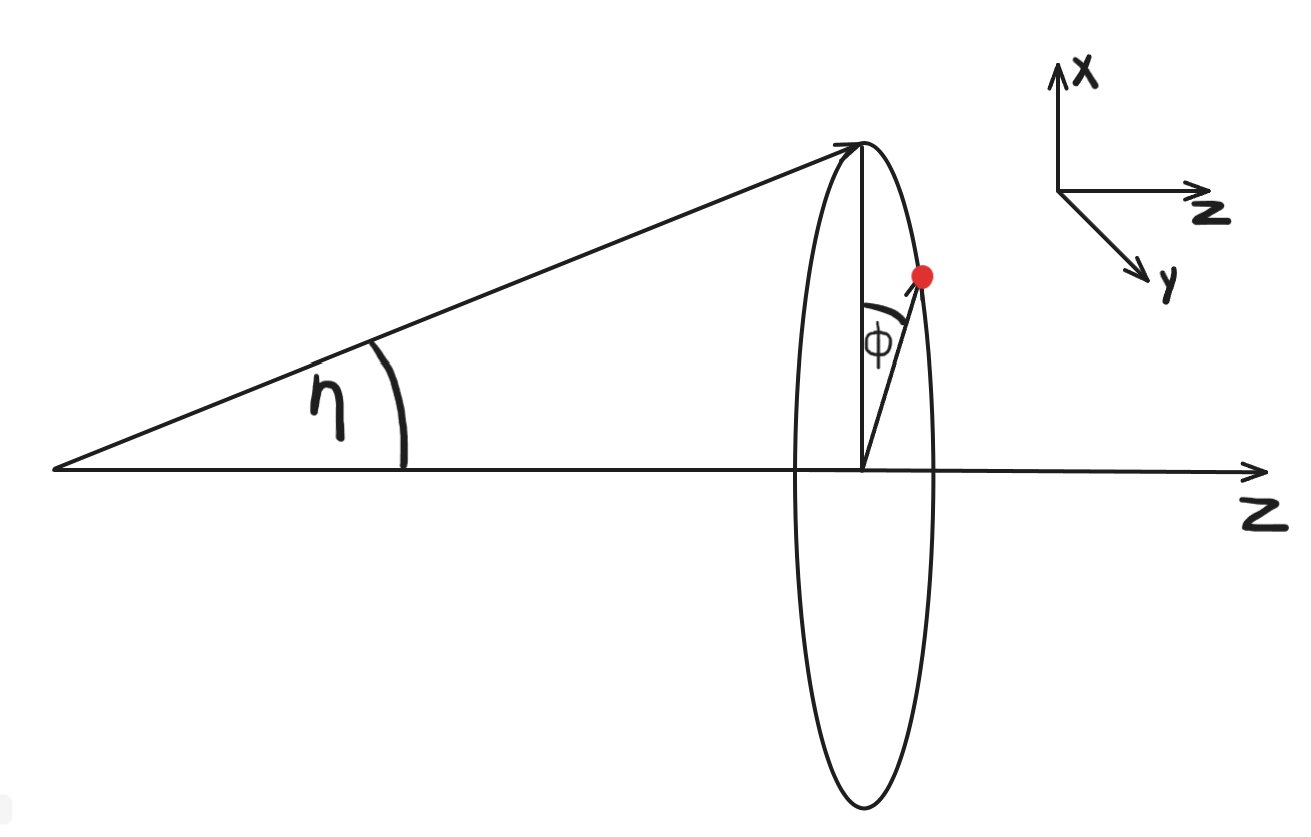

The structure of the particle_features is [N, 30, 4] where N is the total number of jets, 30 is the number of particles, and 4 is the number of particle features, which are $\eta_{rel}$, $\phi_{rel}$, $\rho_{Trel}$, and $mask$, in that order. $mask$ is a boolean that indicates whether or not particle data is zero-padded, meaning zeroes are inserted into the particle features array to preserve data shape. We do not use this value in this project, and thus have not included it in our dataset.

The structure of the jet_features is [N,4] where 4 is the number of jet features, which are $\rho_{T}$, $\eta$, $mass$, and # of particles, in that order. In this project, we do not use any of the jet features other than jet type.

In [3]:
# Function that creates arrays for particle and jet data.
particle_data, jet_data = DataGrabber()

# Prints all jet_features for the first jet.
print("jet_features (first jet):", jet_data[0])

# Prints the first 10 values of the particle_features for the first jet.
print("particle_features (first 10 particles of first jet):\n", particle_data[0, :30])

jet_features (first jet): [ 4. 30.]
particle_features (first 10 particles of first jet):
 [[ 0.06290796  0.05512052  0.36435664]
 [-0.06586371 -0.05907703  0.12440164]
 [-0.0653964  -0.05337463  0.09415382]
 [-0.06459205 -0.05243392  0.07921991]
 [-0.06712561 -0.04849824  0.06635038]
 [ 0.07606371  0.05091094  0.04200844]
 [-0.06959206 -0.05243391  0.04113905]
 [-0.03709203 -0.02491993  0.02250057]
 [ 0.02566628  0.05522707  0.0200865 ]
 [ 0.07745282  0.0475357   0.01692319]
 [-0.05905455 -0.04995673  0.01617971]
 [-0.0626553  -0.02992728  0.01595033]
 [-0.05318715 -0.0550781   0.01538625]
 [-0.07467487 -0.03181437  0.01410781]
 [ 0.03627833 -0.00596839  0.01195867]
 [ 0.05886716  0.03642837  0.00868009]
 [ 0.03880872 -0.01695948  0.00747104]
 [-0.03459206 -0.01741644  0.0074028 ]
 [ 0.04040794  0.077632    0.00496419]
 [ 0.07540796  0.07262952  0.0046213 ]
 [-0.09173921 -0.05520517  0.00351092]
 [ 0.02157012 -0.01936632  0.00320567]
 [ 0.10803359  0.03199346  0.00307138]
 [ 0.00204379

# How can this be visualized?

In [4]:
import matplotlib.pyplot as plt # For creating plots.
import numpy as np # For doing math.

from jetnet.utils import to_image # Package used to convert JetNet data to images.

In [5]:
# Function that generates plots of jets.
def ParticlePlotter(num_plots=4, image_size=80, maxR=0.4):

    # Creates particle and jet arrays.
    particle_data, jet_data = DataGrabber()

    num_types = 5  # Number of plot types is number of jet types: g, t, q, w, z.
    plot_size = image_size  # Size of plots, e.g., 80x80.

    cm = plt.cm.jet.copy()  # Copies colourmap called 'jet' from matplotlib colourmap. This colourmap uses blue for low values, and red for high values.
    cm.set_under(color="white")  # Sets the colour under the colourmap threshold to be white.
    plt.rcParams.update({"font.size": 16})  # Ensures every label has the same font size of 16.

    # Creates subplots. gridspec_kw = {"wspace": 0.25} ensures the horizontal gap between plots is 25% of a subplot's width.
    fig, axs = plt.subplots(nrows=num_types, ncols=num_plots, figsize=(40, 40), gridspec_kw={"wspace": 0.25})

    # Iterates over number of jet types. each value of i corresponds to a row of plots.
    for i in range(num_types):

        # Defines which jet type is being plotted on each row. jet_data[:, 0] is the first column of jet_data, which is the jet type column.
        row_type = jet_data[:, 0] == i

        # Adds the lefthand labels g, t, q, w, z.
        jet_labels = ["g", "t", "q", "w", "z"]
        axs[i][0].text(-(maxR+0.2), 0, jet_labels[i], fontsize=24, ha="right", va="center")

        # Iterates over number of plots to display in each row.
        for j in range(num_plots):

            # Generates the plots using JetNet's to_image() function, which converts the JetNet data to image arrays, using the jet colourmap,
            # interpolation = "nearest" ensures the particles are displayed as squares, vmin and vmax control the colourscale, and extent is the
            # maximum and minimum x and y axis.
            plot = axs[i][j].imshow(
                to_image(particle_data[row_type][j], plot_size, maxR=maxR), # JetNet's to_image() function
                cmap=cm, #colour map
                vmin=1e-8, # min value for a square to be non-white
                vmax=0.05, # max value
                extent=[-maxR, maxR, -maxR, maxR])

            # Disables all axis ticks.
            axs[i][j].tick_params(which="both", bottom=False, top=False, left=False, right=False)

            # Generates x and y labels, as well as jet titles.
            axs[i][j].set_xlabel("$Φ^{rel}$")
            axs[i][j].set_ylabel("$η^{rel}$")
            axs[i][j].set_title(f"Jet {j + 1}")

    # Displays colour bar.
    cbar = fig.colorbar(plot, ax=axs.ravel().tolist(), fraction=0.01)

    # Labels the colour bar.
    cbar.set_label("$P_T^{rel}$")

    plt.show()
    return

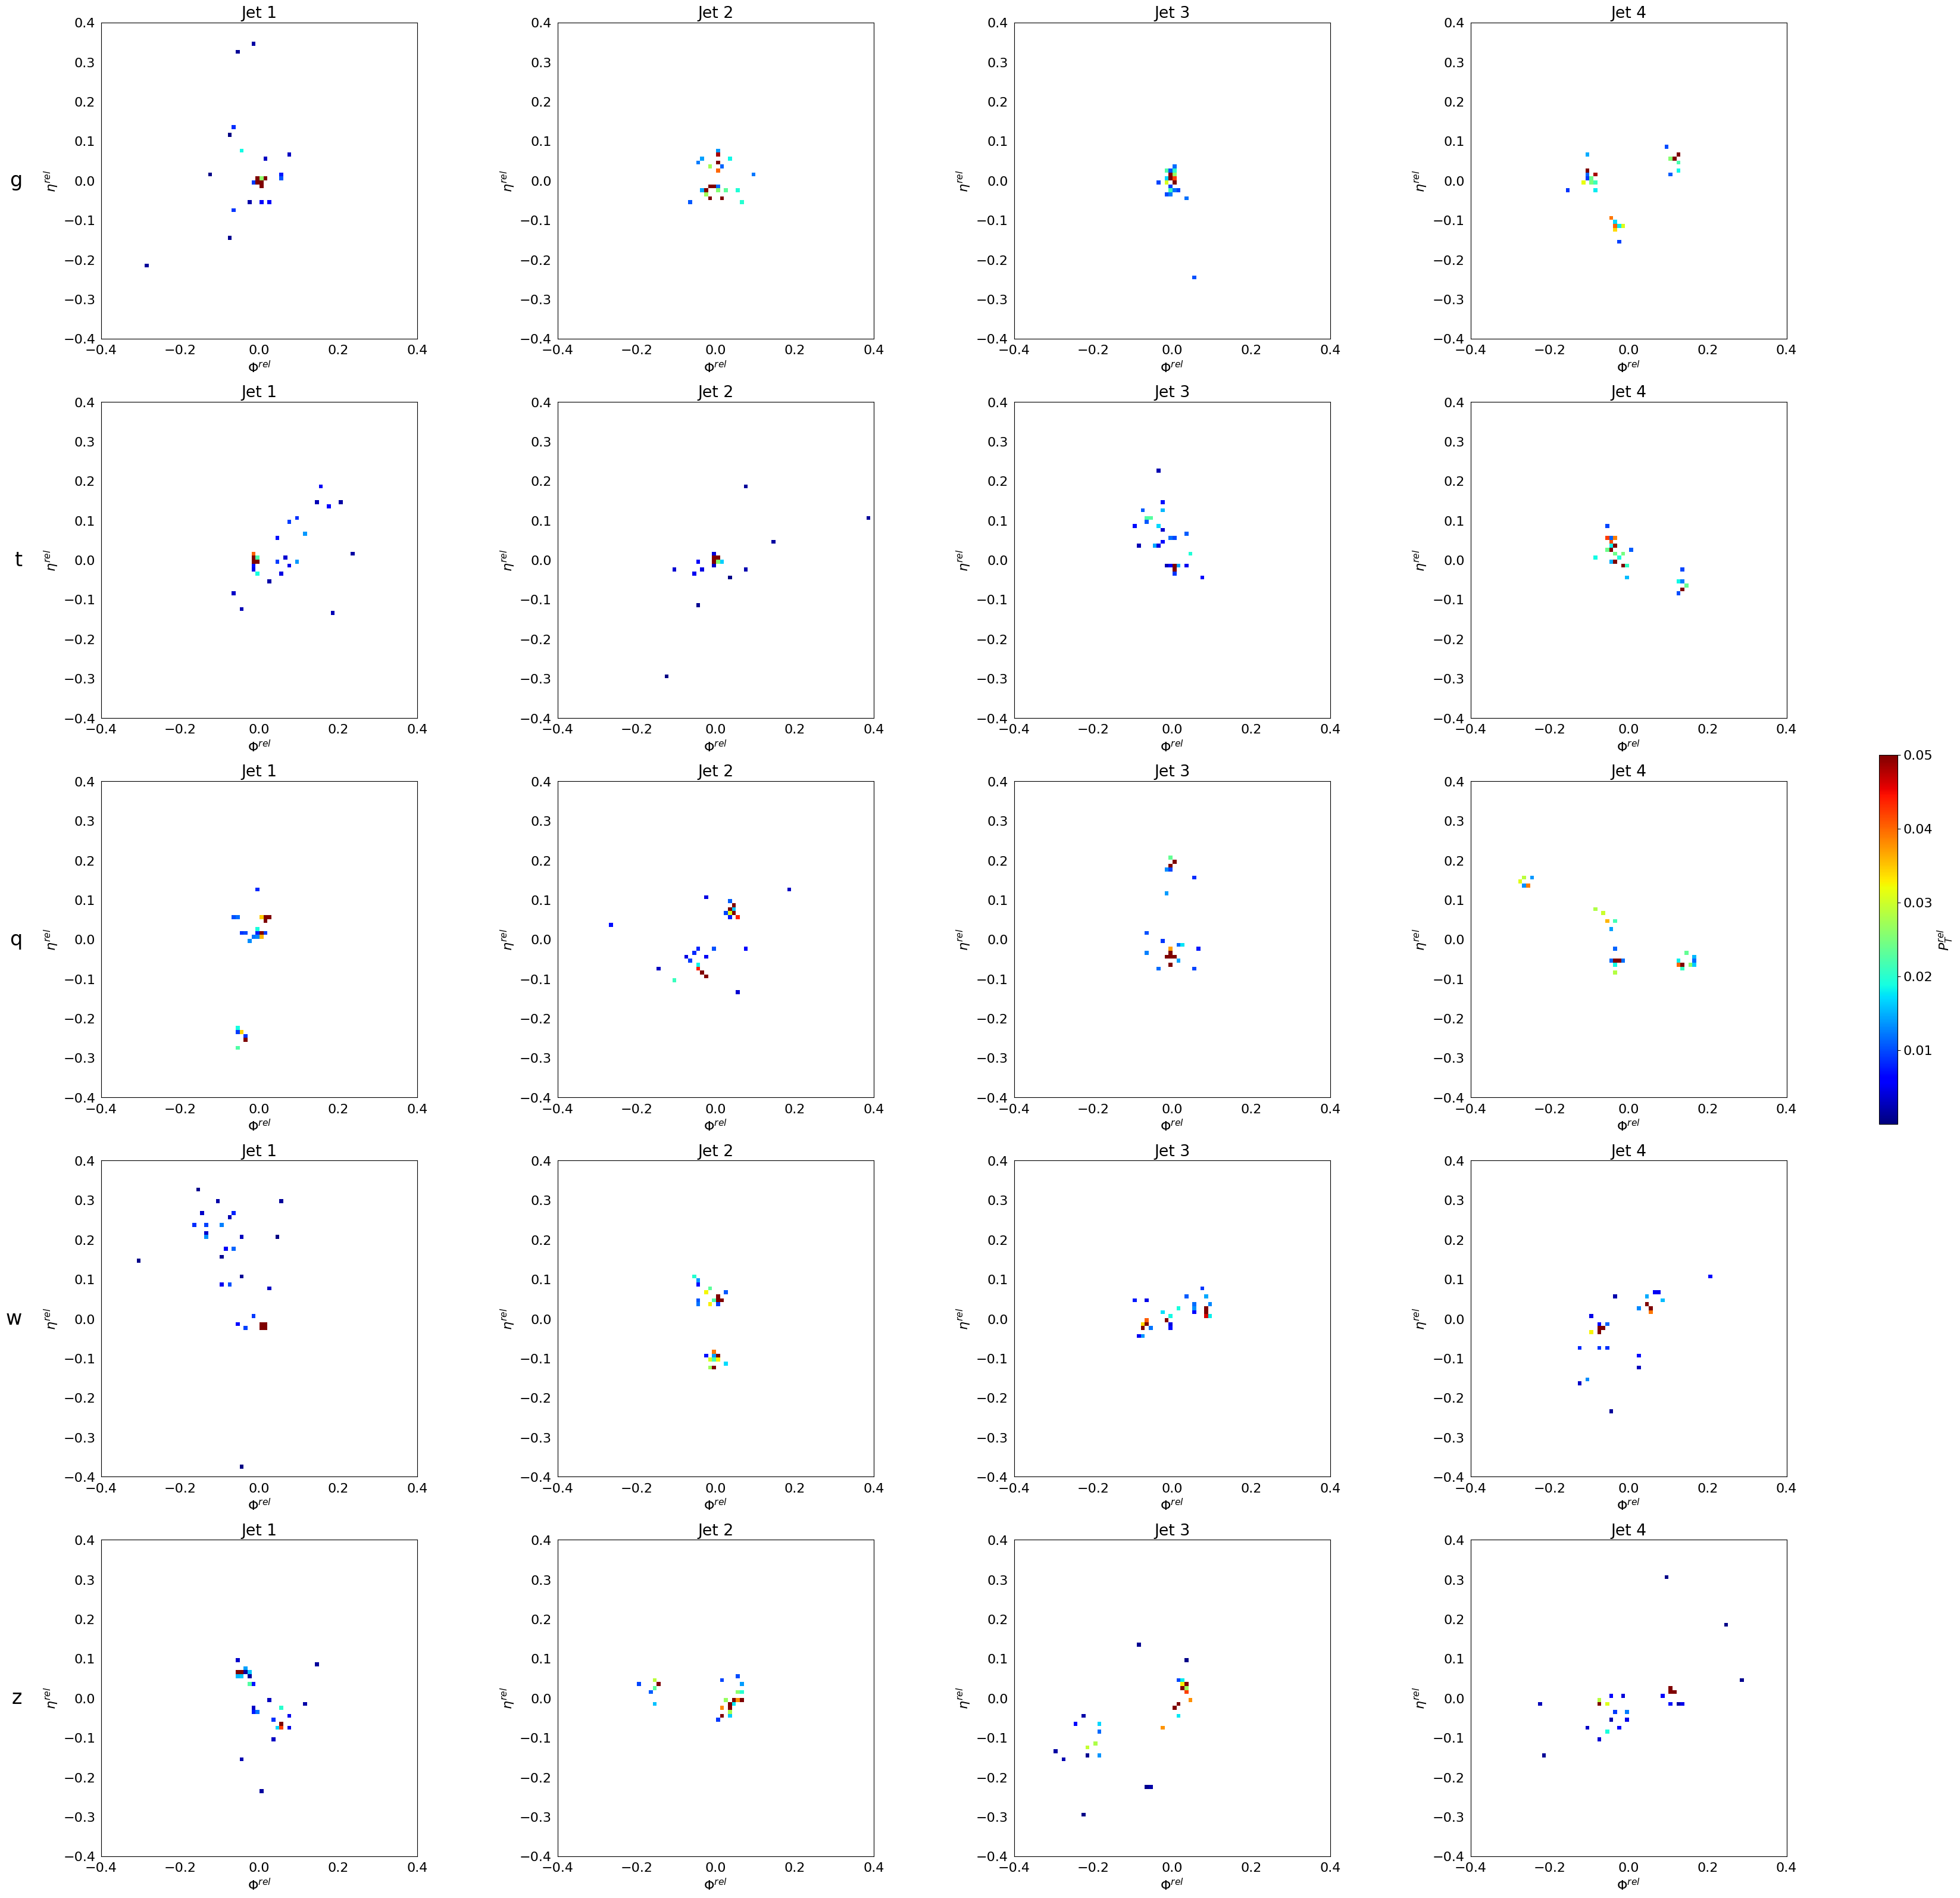

In [6]:
ParticlePlotter(num_plots=4, image_size=80, maxR=0.4)

# Our Goal:

To use two Machine Learning algorithms (ResNet50 and InceptionV3) to categorize images of jets by jet type, as given by the JetNet dataset. In order to do this, we first have to separate the jet data into 5 evenly split groups by particle type:

# Machine Learning

Machine learning is a domain focused on creating algorithms that have the ability to "learn" patterns from data that it is trained on and then be able to make accurate inferences when presented with new data. 

### Neural Networks
Neural Networks are one of the most important and popular algorithms in machine learning. They are used for a vast variety of tasks such as computer vision, natural language processing, and speech recognition. They were originally created to mimic the human brain and how it behaves. Neural networks consist of interconnected nodes (neurons) that are organized into layers. A simple neural network architecture has 3 layers which are the input layer which processes and analyzes the data, hidden layer which analyzes the data from the previous layer and passes it forward, and output layer which gives the final result of the neural network.

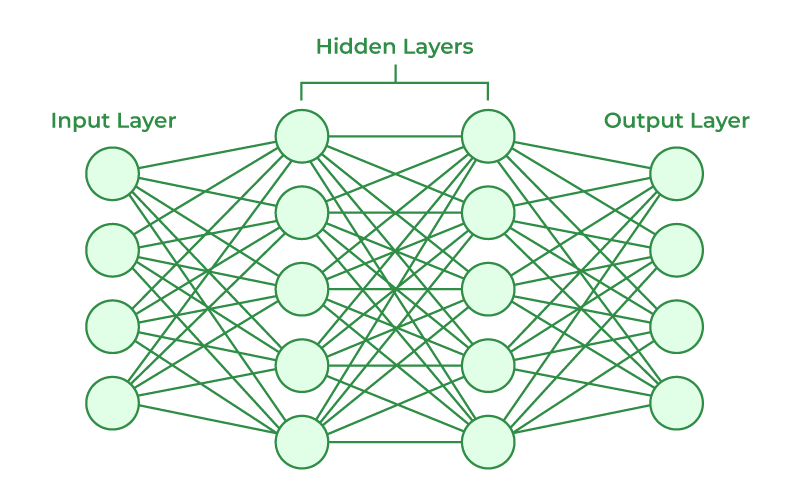

### Convolutional Neural Networks
Convolutional Neural Networks are a type of neural network that are most often used for classification and computer vision. 

https://www.youtube.com/shorts/W8-k_ojtUFU

They have three main layers which are the convolutional layer, pooling layer, and fully connected layer these are just types of hidden layers that are specific to CNNs 

Types of CNNs: LeNet-5, AlexNet, ResNet, and Inception (GoogLeNet)

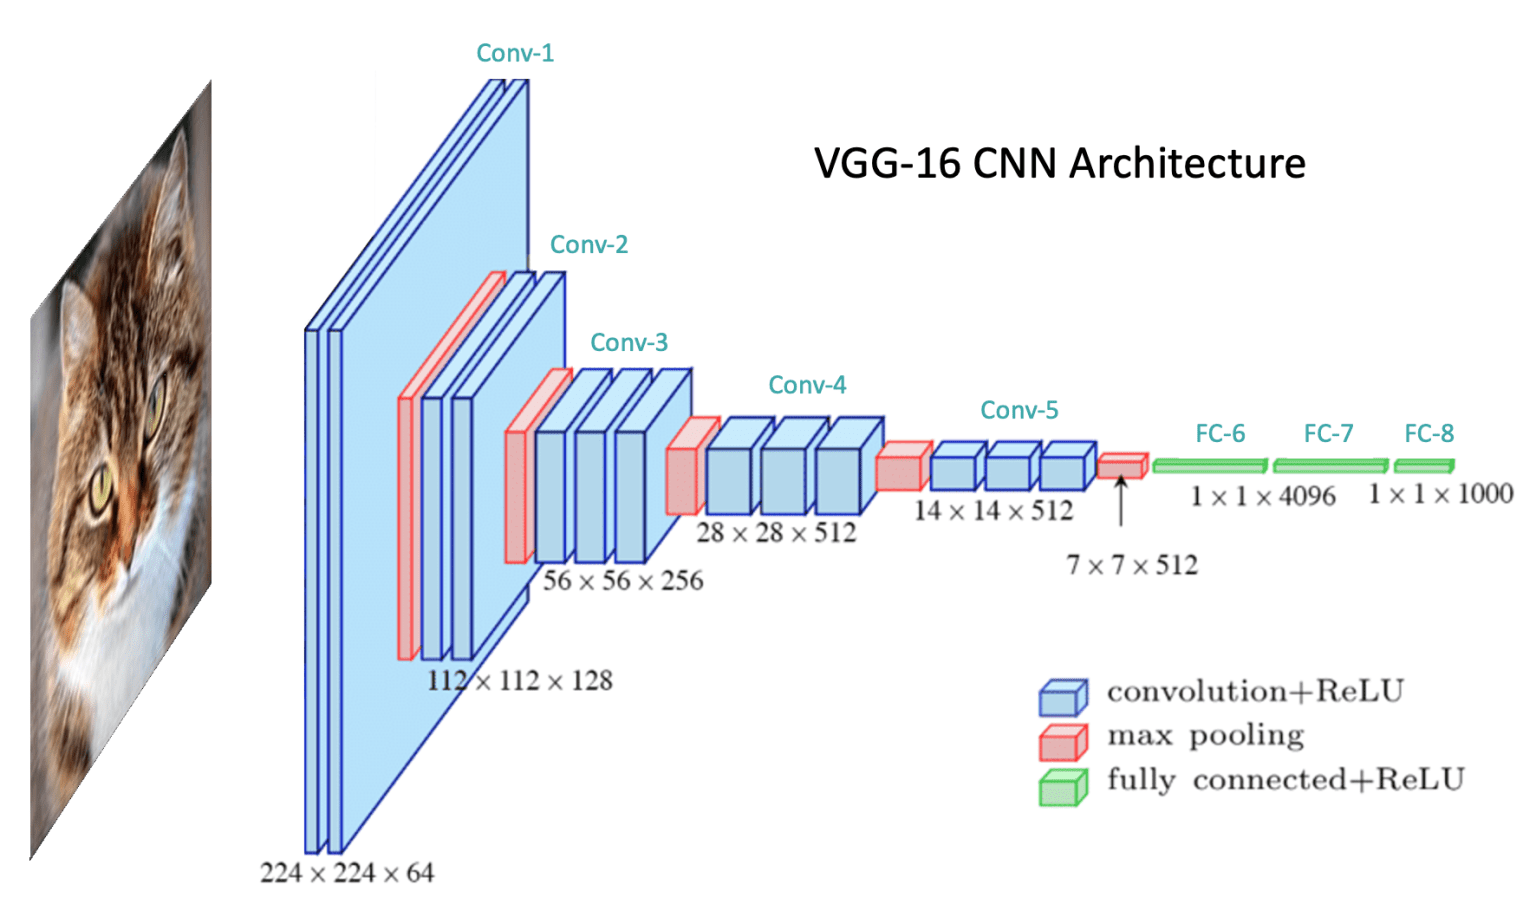

From the image you can see that the neurons in CNNs differ slightly from regular neural networks in the way that their neurons are structured. CNNs arranges its neurons in three dimension (width, height, depth).  


In [7]:
import numpy as np
def DataSetCreation(jet_data, particle_data, numJets=5000, fracTrain=0.8):
    
    # Extracts jet types from first column of jet_data as integers. While the jet_type dictionary entry appears to contain strings,
    # they can be stored as integers using .astype(int).
    jet_type_array = jet_data[:, 0].astype(int)

    # Do floor division to find number of jets per jet type based on numJets.
    jets_per_type = numJets // 5

    # Create empty lists for training and validation indices.
    train_indices = []
    valid_indices = []

    # Print number of jets per type.
    print("Jet type counts before split:")
    for i in range(5):
        print(i, np.sum(jet_type_array == i))
    print(f"\n")
    
    # Function that splits jet indices into two arrays, one for training data, and one
    # for validation data.
    def split_indices(indices):
        split = int(len(indices) * fracTrain)
        return indices[:split], indices[split:]

    # Iterate through each jet type
    for i in range(5):

        # Finds all indices where jet type is i. For the first iteration, this creates a list of all indices where jet_type is 0 (g jets).
        type_indices = np.where(jet_type_array == i)[0]

        # From this list, select randomly to build another list of length jets_per_type. replace=False ensures each element is only chosen once.
        selected_jets = np.random.choice(type_indices, jets_per_type, replace=False)

        # Create two lists of indices, one for training and one for validation, and use split_indices function.
        train_i, valid_i = split_indices(selected_jets)

        # Append selected indices to training and validation indices lists.
        train_indices.append(train_i)
        valid_indices.append(valid_i)
        
    # We found this to be an easy way to convert our lists to numpy arrays. (This did something else in a previous iteration of our code,
    # but if it ain't broke, don't fix it).
    trainIndices = np.concatenate((train_indices))
    validIndices = np.concatenate((valid_indices))

    #Prints first 10 indices selected from jet_data that correspond to jets that will be used to train the model.
    print("First 10 selected indices from the jet data passed to the training indices array.")
    print(trainIndices[:10])
    print(f"\n")

    # Shuffles the indices.
    np.random.shuffle(trainIndices)
    np.random.shuffle(validIndices)
    
    # Creates final arrays for both particle and jet datasets.
    train_particles = particle_data[trainIndices]
    valid_particles = particle_data[validIndices]
    train_jets = jet_data[trainIndices]
    valid_jets = jet_data[validIndices]

    # Prints unique jet types as an array (should be from 0 to 4) and the count of each jet type (should be equal across each type).
    print("Training jet type counts after split:")
    print(np.unique(train_jets[:,0], return_counts=True))
    
    print("Validation jet type counts after split:")
    print(np.unique(valid_jets[:,0], return_counts=True))
    print(f"\n")
    
    # Returns the four arrays.
    return train_particles, valid_particles, train_jets, valid_jets

As seen below, the data is now organized into jet arrays, and corresponding particle arrays. The rows of particle features containing all 0's are Jets with less than 30 particles.

In [8]:
DataSetCreation(jet_data, particle_data, numJets=5000, fracTrain=0.8)

Jet type counts before split:
0 177252
1 170679
2 177945
3 177172
4 176952


First 10 selected indices from the jet data passed to the training indices array.
[330822 123431 551479 732335 221723 499218 391839 105607 280332  83575]


Training jet type counts after split:
(array([0., 1., 2., 3., 4.]), array([800, 800, 800, 800, 800]))
Validation jet type counts after split:
(array([0., 1., 2., 3., 4.]), array([200, 200, 200, 200, 200]))




(array([[[-2.46804729e-02,  2.93346383e-02,  1.78499714e-01],
         [-2.52899099e-02,  2.51013860e-02,  1.06290668e-01],
         [-2.60406286e-02,  3.55769172e-02,  9.95840430e-02],
         ...,
         [-1.38205901e-01, -7.76691884e-02,  3.12672788e-03],
         [-1.04928546e-01,  3.47118787e-02,  3.02938931e-03],
         [ 8.48965645e-02, -4.17435579e-02,  2.64225411e-03]],
 
        [[ 1.33910300e-02,  3.99140380e-02,  5.87163568e-01],
         [ 1.26534905e-02,  3.70443054e-02,  1.43874466e-01],
         [-5.16090468e-02, -2.10212797e-01,  4.42906581e-02],
         ...,
         [-6.95274919e-02, -2.16595605e-01,  9.90509405e-04],
         [-1.61173984e-01, -8.54562148e-02,  8.27527372e-04],
         [-9.16090086e-02, -2.15215296e-01,  7.20573531e-04]],
 
        [[-6.51680753e-02,  8.86760559e-03,  4.52784300e-01],
         [-6.61495999e-02,  1.54675823e-02,  1.12553179e-01],
         [ 6.27892241e-02, -6.75459020e-03,  6.28081858e-02],
         ...,
         [ 1.37331873e

After the data has been stratified, the jet images can be created. The images used are created using JetNet's to_image() function. This function creates arrays of pixel data of size 224 x 224, with each pixel's value corresponding to the $\rho_{Trel}$ of a particle at that location. If there is no particle at a pixel's location, the $\rho_{Trel}$ is 0. Since the ResNet model requires an input of 3 colour channels (Red, Green, Blue), and the to_image() function outputs images of 1 colour channel (greyscale images), we have chosen to simply duplicate the image across 3 channels.


In [10]:
def jet_to_tensor(jet_particles, im_size=224, maxR=0.4):

    # Number of colour channels required for ResNet (RGB). Since the to_image() images are greyscale,
    # each R,G,B is equivalent for each pixel.
    num_channels = 3

    # Converts jet particle data to images.
    jet_image = to_image(jet_particles, im_size=im_size, maxR=maxR)

    # defines maximum and minimum P_T, similar to the data analysis done earlier.
    vmax_plot = 0.05
    vmin_plot = 1e-8

    # Limits the values in each image to the specified ranges.
    jet_image = np.clip(jet_image, vmin_plot, vmax_plot)

    # Normalizes the pixels to a range of 0 to 1. i.e. a P_T of 1e-8 is white, and a P_T of 0.05 is black, with values in-between being grey.
    jet_image = (jet_image - vmin_plot) / (vmax_plot - vmin_plot)

    # Converts the single channel (greyscale) image into a 3-channel RGB image, with each R, G, and B channel having the same value.
    # This allows the images to be used with ResNet, as it requires inputted images to have 3 colour channels.
    jet_image_3ch = np.stack([jet_image]*num_channels, axis=0)

    # returns the 3 channel images as tensors.
    return torch.tensor(jet_image_3ch, dtype=torch.float32)

In [13]:
import optuna # Optuna is a library used for hyperparameter tuning.

def objective(trial, params, train_dataset, valid_dataset, model_name = 'resnet', deviceUsed = 'cuda', weights = None):
    params["learning_rate"] = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    params["batch_size"] = trial.suggest_categorical("batch_size", [16, 32, 64])
    params["weight_decay"] = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    params["optimizer"] = trial.suggest_categorical("optimizer", ['Adam'])
    params["num_epochs"] = trial.suggest_int("num_epoch", 1, 5)
    print(params)

    return model_train(deviceUsed = deviceUsed, params=params, train_dataset=train_dataset, valid_dataset=valid_dataset, 
                       model_name=model_name, weights = weights)

def tune_model(params, train_dataset, valid_dataset, model_name, deviceUsed, weights):
    study_func = lambda trial: objective(trial, params, train_dataset, valid_dataset, model_name, deviceUsed, weights)
    study = optuna.create_study(direction='maximize')
    study.optimize(study_func, n_trials=10)

    return study.best_trial

# The Models We Used

## ResNet-50
Resnet-50 is a CNN that was created in 2015 by Microsoft Research and was designed for image recognition and computer vision

It introduces a concept called residual learning which allows the network to preserve information and gradients and this allows deeper models to viable. Before ResNet there was a problem of vanishing gradients that plagued deeper networks but ResNet fixed this.

ResNet-50 has 50 layers with learnable weights and uses something called skip connections to bypass layers which allows for gradients and information to flow easily through the network.
After the the 50 layers that ResNet has there is then batch normalization and ReLU activation. These layers handle things such as extracting features from the input images for example things like edges, textures and shapes.

After the convolutional layers come the max pooling layers of the model which reduce the spatial dimensions of the features while also keeping the most important features


The final step of ResNet-50 is the FC layers (Fully Connected Layers)



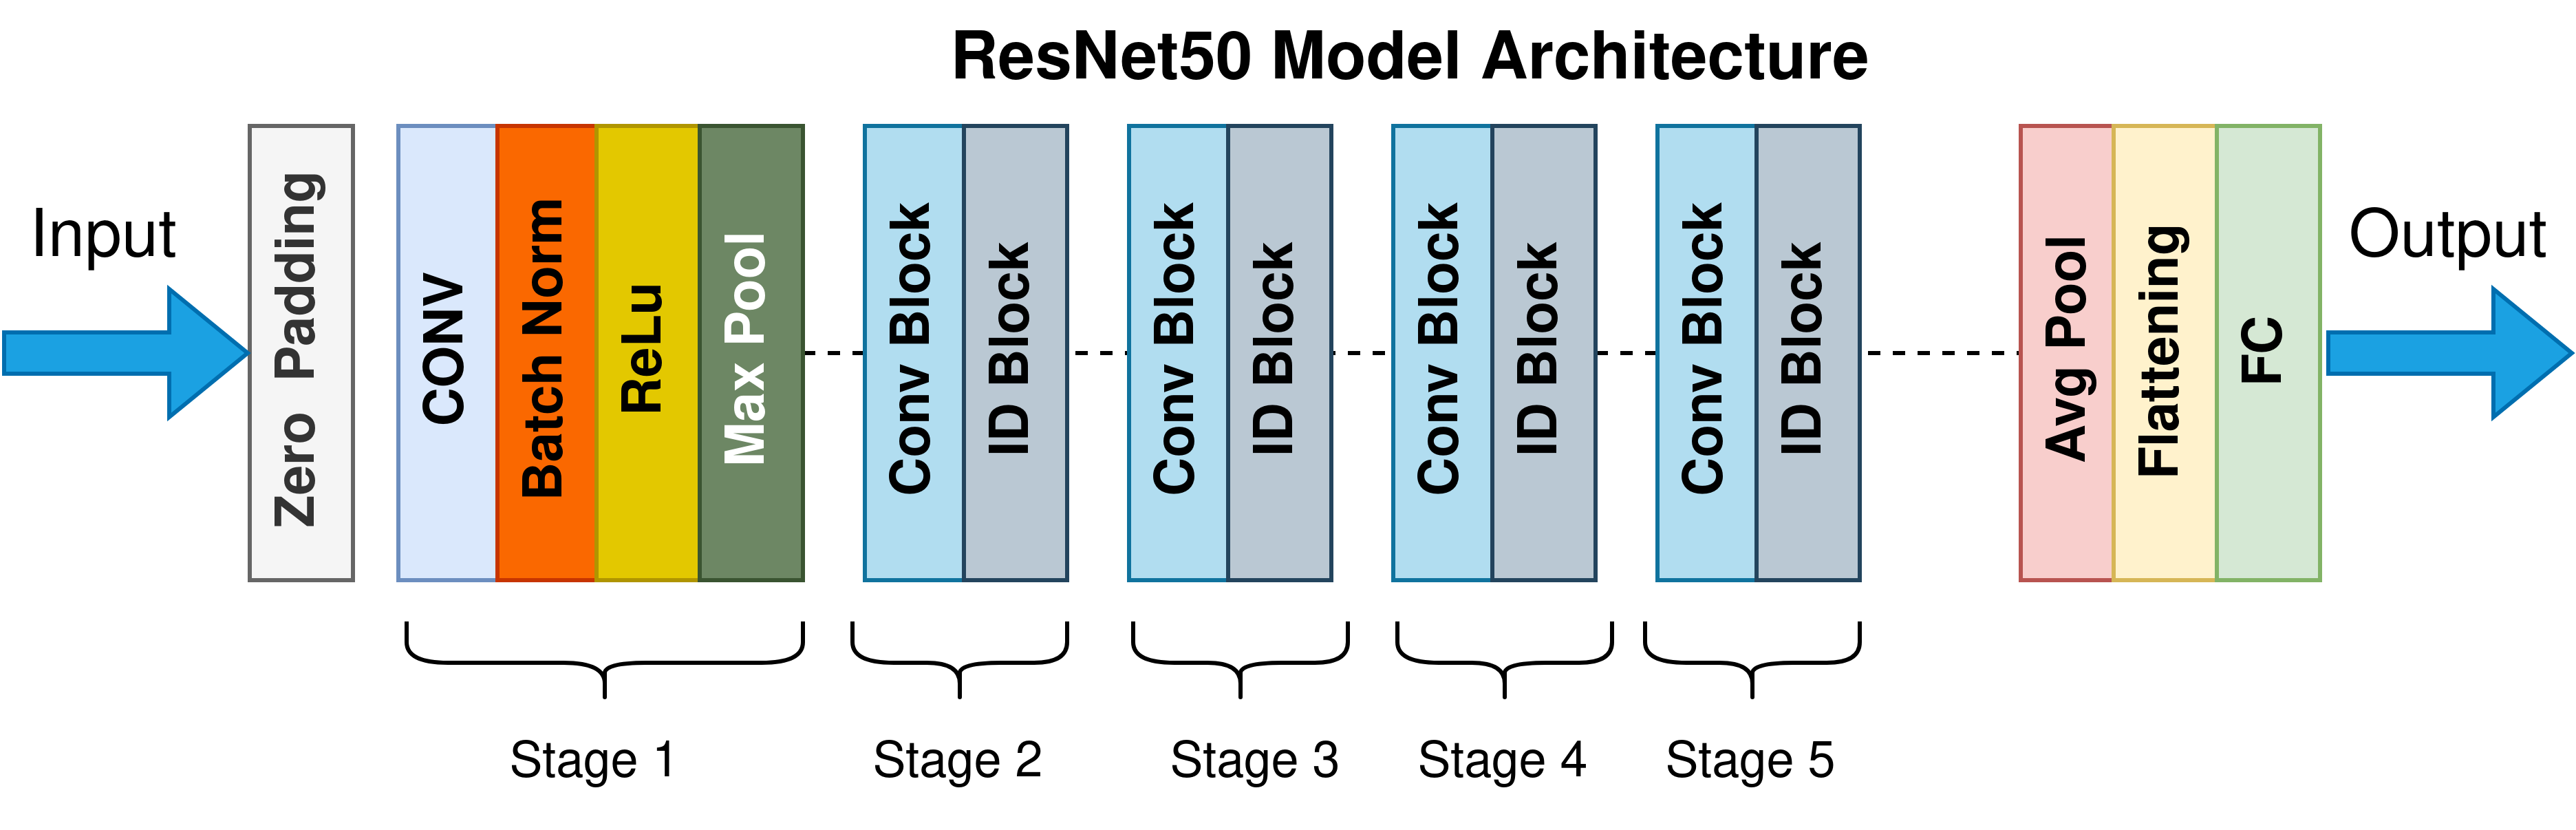


Link to ResNet Simulation: https://tensorspace.org/html/playground/resnet50.html

## InceptionV3

InceptionV3 is another CNN, it was developed by Google and is a part of the inception family (originally known as GoogLeNet)

It has 48 layers with multiple filter sizes and asymmetric convolutions

It takes in a default input size of 299x299x3 which is larger than the 224x224 input size of ResNet 

Its layers include an input layer, stem layer which has convolution and pooling layers inside, average pooling layer, dropout layer, fully connected, softmax, and finally a classification layer 

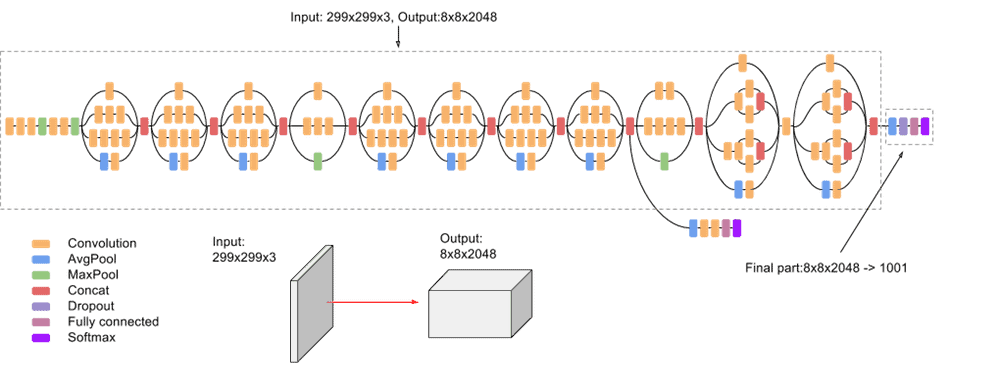

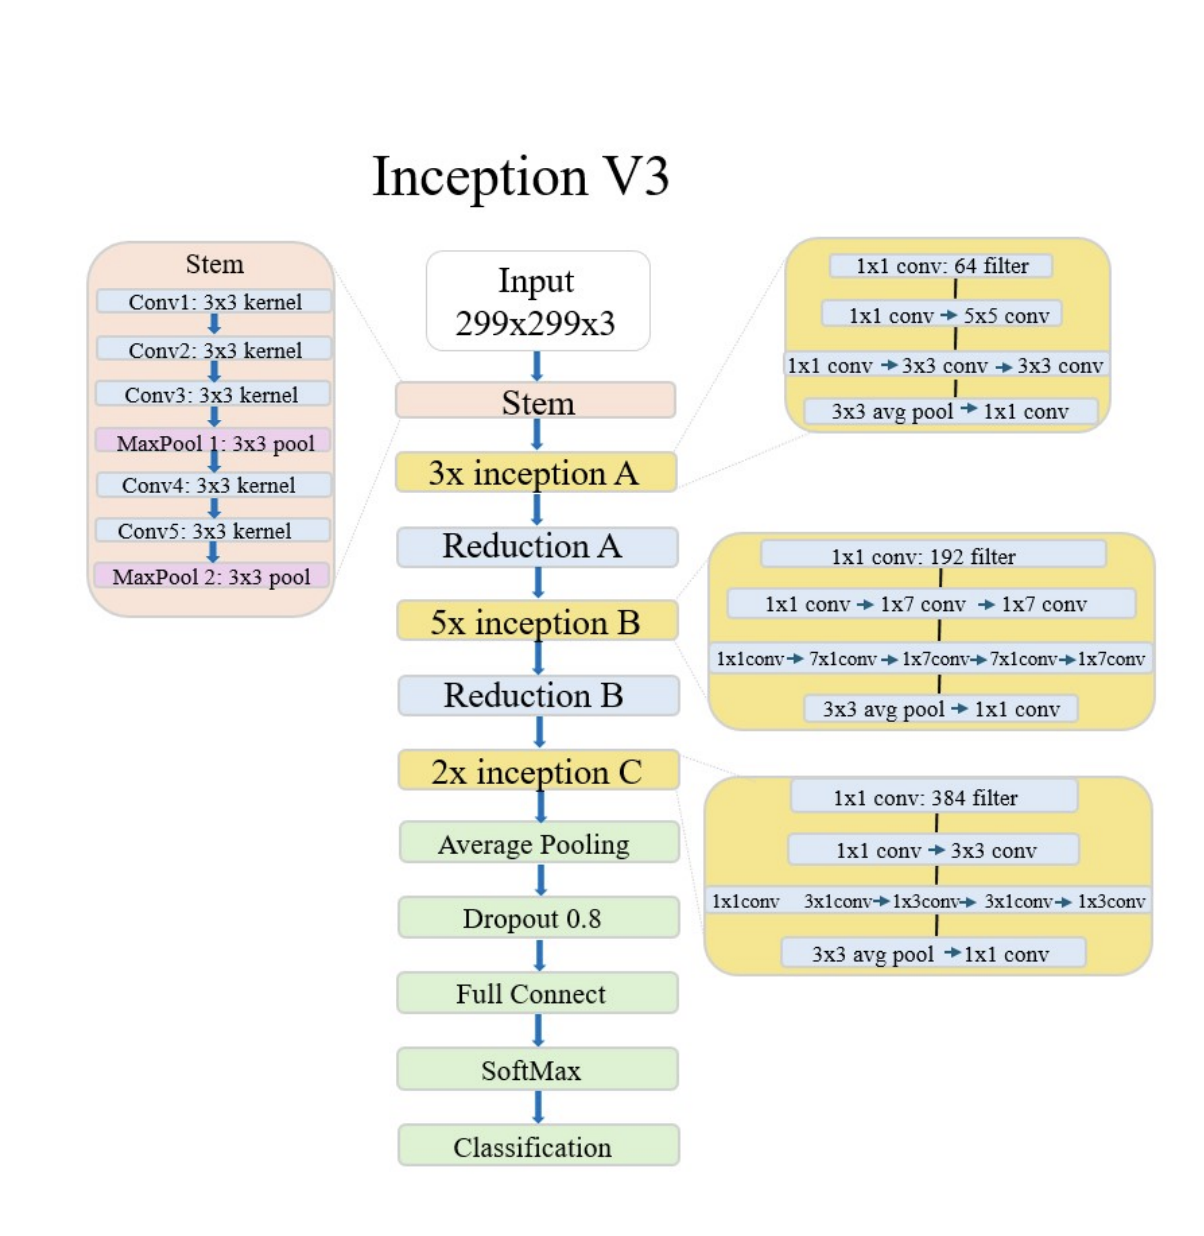

### Data Preparation

In [1]:
import torch # Provides tools for tensor computation and general machine-learning.
from torch.utils.data import TensorDataset, DataLoader #
import torch.nn as nn # Contains functions for neural networks (Cross Entropy Loss)
import torch.optim as optim # Contains optimization algos (Adam, SGD)
from torchvision import models # Contains the prebuilt models from pytorch

In order to insert these images to the model, they must be packaged appropriately with their jet type labels. The function below creates lists of particle_data and jet_data using DataGrabber(), stratifies this data with DataSetCreation(), creates the images using jet_to_tensor(), and then turns these images into tensors using torch/pytorch, which are packages used for machine learning.

In [15]:
def data_init(im_size = 224, num_jets = 5000, fracTrain = 0.8, maxR = 0.4, deviceUsed = "cuda", batch_size=32, num_show = 4):
    
    # Chooses device to perform computations on. Options are "cpu", "cuda", "mlp", where "cuda" refers to an nvidia graphics card and "mlp" refers to the apple silicon chip
    device = torch.device(deviceUsed)

    # Generate particle and jet lists.
    particle_data, jet_data = DataGrabber()

    # Call DataSetCreation with jet and particle data to create training and validation lists.
    train_particles, valid_particles, train_jets, valid_jets = DataSetCreation(jet_data, particle_data, num_jets, fracTrain)

    # Iterates over each jet in either subset, converts it to a tensor image using to_image(), and puts these tensors in a list.
    image_train_list = [jet_to_tensor(train_particles[i], im_size=im_size, maxR=maxR) for i in range(len(train_jets))]
    image_valid_list = [jet_to_tensor(valid_particles[i], im_size=im_size, maxR=maxR) for i in range(len(valid_jets))]

    # Takes each list of image tensors, and concatenates them along an extra dimension. This is done because
    # ResNet requires a tensor input, and previously the image data was organized into lists of tensors.
    image_train_tensor = torch.stack(image_train_list, axis=0)
    image_valid_tensor = torch.stack(image_valid_list, axis=0)

    # Takes the jet type column of the training and validation jet arrays and converts them to tensors. Data type is also set to long, which is
    # required by ResNet.
    label_train_tensor = torch.tensor(train_jets[:,0], dtype=torch.long)
    label_valid_tensor = torch.tensor(valid_jets[:,0], dtype=torch.long)

    # TensorDataset() combines the particle features and jet type tensors into a single "package". This allows the images and labels to be handled
    # as a single object.
    train_dataset = TensorDataset(image_train_tensor, label_train_tensor)
    valid_dataset = TensorDataset(image_valid_tensor, label_valid_tensor)

    # Show the first 4 images from the training set as an example.
    fig, axs = plt.subplots(1, num_show, figsize=(12, 3))

    # iterates over number of plots to show as an example.
    for i in range(num_show):
        # plot the X_train_tensor data after moving it back to the CPU, and transpose the tensor to be valid with matplotlib.
        example_plot = image_train_tensor[i].numpy().transpose(1,2,0)  # Colour, Height, Width -> Height, Width, Colour
        axs[i].imshow(example_plot)
        axs[i].axis("off")
        axs[i].set_title(f"Jet {i+1}")
    plt.show()

    print(f"Initializing data on {deviceUsed} with {num_jets} jets, size {im_size} images, and {fracTrain*100} % of images being used to train model.")

    # Return the training and validation datasets, which include both the images and jet type labels.
    return train_dataset, valid_dataset

### How is the model initialized?

The models are initialized using the pytorch models library and we also define two other important things for the model which are the loss function and the optimizer which will both be very important during training.

In [16]:
# model_init function
def model_init(deviceUsed = 'cuda', weight_decay = 1e-3, model_name = "resnet",
              weights = "IMAGENET1K_V2", lr = 1e-4):

    device = torch.device(deviceUsed)
    
    # Defines the model model itself. weights=None means the model is loaded in an untrained state, as for our purposes we want to train
    # the model with pretrained weights.
    if model_name == 'resnet':
       
        model = models.resnet50(weights=weights)

    if model_name =='inception':
        
        model = models.inception_v3(weights=weights)

    # Redefines models's fully connected (FC) layer to have the standard 2048 input features and 5 output classes.
    # Normally the output features are 1000, which correspond to 1000 types of images ResNet can identify. However, in our case,
    # ResNet only has to identify 5 different types of images.
    num_classes = 5
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    # Moves model to the GPU
    model = model.to(device) # rip graphics card :(

    # Defines a function using torch.nn's CrossEntropyLoss(). This function compares the model's prediction for each jet type
    # against the true jet type and returns a value that represents how wrong the prediction is.
    lossFunction = nn.CrossEntropyLoss()

    # Defines an optimizer function using Adam (Adaptive movement estimation). This is an algorithm that nudges the model in the correct direction after each guess.
    # The optimizer updates the ResNet parameters, and lr=1e-4 is the learning rate, which can be considered how hard the optimizer nudges the model in
    # the correct direction.
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    return model, lossFunction, optimizer

In [ ]:
def early_stop(delta=0, stop_threshold=2, val_loss=None, early_stop_count=0, best_loss=None):
    '''
    Check if model should stop early during training

    Returns: boolean
    '''

    stop_training = False

    # check if best_loss is either none for the first check or if the loss value is less than the best loss - delta
    if best_loss is None or val_loss < best_loss - delta:
        # set best_loss to the new best loss
        best_loss = val_loss
        # set the count back to zero since we have a new best loss
        early_stop_count = 0
    else:
        # otherwise if the val_loss is larger than the best loss then that means we must increment the count
        early_stop_count += 1
        #check if the count has gone above the stop_threshold and if it has set stop_training to true
        if early_stop_count >= stop_threshold:
            stop_training = True
    return stop_training, early_stop_count, best_loss

In [ ]:
import optuna # Optuna is a library used for hyperparameter tuning.

In [ ]:
def objective(trial, params, train_dataset, valid_dataset, model_name = 'resnet', deviceUsed = 'cuda', weights = None):
    params["learning_rate"] = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    params["batch_size"] = trial.suggest_categorical("batch_size", [16, 32, 64])
    params["weight_decay"] = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    params["optimizer"] = trial.suggest_categorical("optimizer", ['Adam'])
    params["num_epochs"] = trial.suggest_int("num_epoch", 1, 5)
    print(params)

    return model_train(deviceUsed = deviceUsed, params=params, train_dataset=train_dataset, valid_dataset=valid_dataset, 
                       model_name=model_name, weights = weights)

In [ ]:
def tune_model(params, train_dataset, valid_dataset, model_name, deviceUsed, weights):
    study_func = lambda trial: objective(trial, params, train_dataset, valid_dataset, model_name, deviceUsed, weights)
    study = optuna.create_study(direction='maximize')
    study.optimize(study_func, n_trials=10)

    return study.best_trial

### How is the model trained?

The model train function implements the training and validation loop used to train the model. If the tuner function has been called and passes params then it will begin doing a hyperparameter search using optuna. Otherwise the model will begin training normally using the passed arguments. The early stop function will check if the val loss has not

In [17]:
def model_train(num_epochs = 5, params=None, train_dataset=None, valid_dataset=None, model_name=None,
                weights = None, deviceUsed = 'cuda', lr = 1e-5, weight_decay = 1e-3, batch_size=32):

    # Define the device we are using 'cuda' or 'cpu'
    device = torch.device(deviceUsed)

    # Initialize variables for early stop function
    stop = False
    best_loss = None
    early_stop_count = 0

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size)
    model, lossFunction, optimizer = model_init(deviceUsed = device , lr=lr, weight_decay=weight_decay, weights = weights, model_name = model_name)

    # check if a dictionary for params was passed and if true then run study and tune hyperparameters.
    if params != None:
        train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
        valid_loader = DataLoader(valid_dataset, batch_size=params['batch_size'])
        num_epochs=params['num_epochs']

        model, lossFunction, optimizer = model_init(deviceUsed = device, lr=params['learning_rate'], weight_decay=params['weight_decay'], weights = weights, model_name = model_name)

    for epoch in range(num_epochs):

        # model is trained on the training set
        model.train() # Initialize model in training mode.
        running_loss = 0.0 # Initialize running loss value.

        for images, labels in train_loader: # Iterate through particle images and jet type labels in training dataloader. Iterates through each batch.

            images, labels = images.to(device), labels.to(device) # Send images and labels to chosen device.
            optimizer.zero_grad() # calling zero grad on the optimizer before training zeroes out the gradients so they don't acculumate over training steps
            if model_name == 'resnet': 
                outputs = model(images) # model does a forward pass on inputs and give output logits
            elif model_name == 'inception':
                outputs, _ = model(images) # model does a forward pass on inputs and give output logits
            loss = lossFunction(outputs, labels) # The loss is computed using the loss function that we returned from model_init
            loss.backward() # loss.backward() method computes the models gradients 
            optimizer.step() # optimizer.step() tells the optimizer to perform an optimization step and update the model parameters (weights and biases) using the gradients
            running_loss += loss.item() * images.size(0) # running loss calculates the total loss across the whole dataset while training. Loss.item() converts the tensor to a python scalar and images.size(0) takes the batch size from the tensor.

        train_loss = running_loss / len(train_loader.dataset) # 

        # model is evaluated on validation set
        model.eval() # set model to training mode.
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = lossFunction(outputs, labels)
                running_val_loss += loss.item() * images.size(0)
                predicted = torch.argmax(outputs, dim=1) # The predicted value from the model is saved in the predicted variable
                total += labels.size(0) # The total number of elements in the labels array, size(0) takes the batch size from the tensor
                correct += (predicted == labels).sum().item() # Add to correct whenever a predicted value matches the label, .item() converts tensor to python scalar

            val_loss = running_val_loss / len(valid_loader.dataset) # Loss per image
            val_acc = correct / total # Average accuracy on the validation set

            print(f"Epoch {epoch+1}: Train loss {train_loss:.4f}, Val loss {val_loss:.4f}, Val acc {val_acc:.4f}")

        # early stop check
        stop, early_stop_count, best_loss = early_stop(stop_threshold=2, val_loss=val_loss, best_loss=best_loss, early_stop_count=early_stop_count)

        # Check stop and if true stop training 
        if stop == True:
            print(f"Epoch: {epoch+1} has been stopped early")
            break

    return val_acc

In [18]:
params = {
    'learning_rate': 1e-4,
    'batch_size': 32,
    'weight_decay': 1e-3,
    'num_epochs': 1
}

# ResNet Model

Jet type counts before split:
0 177252
1 170679
2 177945
3 177172
4 176952


First 10 selected indices from the jet data passed to the training indices array.
[769308 581108 861533 619946 765496 170358 462941 764532 433043 762067]


Training jet type counts after split:
(array([0., 1., 2., 3., 4.]), array([160, 160, 160, 160, 160]))
Validation jet type counts after split:
(array([0., 1., 2., 3., 4.]), array([40, 40, 40, 40, 40]))




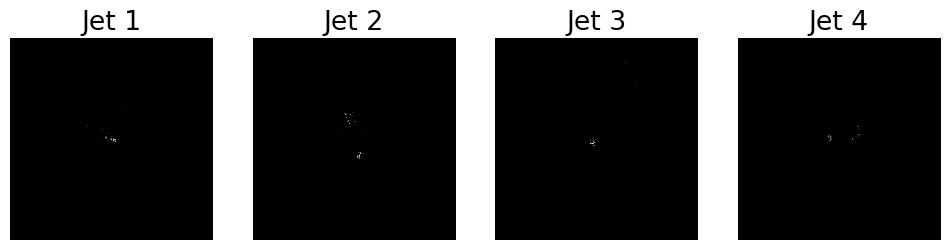

Initializing data on cuda with 1000 jets, size 224 images, and 80.0 % of images being used to train model.


In [19]:
# initialize data for resnet model
train_dataset, valid_dataset = data_init(im_size = 224, num_jets = 1000, fracTrain = 0.8, maxR = 0.4, deviceUsed = "cuda")

In [20]:
best_resnet = tune_model(train_dataset = train_dataset, valid_dataset = valid_dataset, model_name = 'resnet', params=params, deviceUsed='cuda', weights = "IMAGENET1K_V2")

[I 2026-03-20 21:45:20,868] A new study created in memory with name: no-name-d08ecd32-cfa2-48d5-885a-9e792d5a43e0


{'learning_rate': 0.0004668935408966549, 'batch_size': 64, 'weight_decay': 9.939563545391503e-05, 'num_epochs': 5, 'optimizer': 'Adam'}
Epoch 1: Train loss 1.5384, Val loss 1.6096, Val acc 0.2200
Epoch 2: Train loss 1.2846, Val loss 1.6120, Val acc 0.2550
Epoch 3: Train loss 1.0375, Val loss 1.6092, Val acc 0.1950
Epoch 4: Train loss 0.7792, Val loss 1.6047, Val acc 0.2050


[I 2026-03-20 21:45:42,581] Trial 0 finished with value: 0.22 and parameters: {'lr': 0.0004668935408966549, 'batch_size': 64, 'weight_decay': 9.939563545391503e-05, 'optimizer': 'Adam', 'num_epoch': 5}. Best is trial 0 with value: 0.22.


Epoch 5: Train loss 0.4960, Val loss 1.5743, Val acc 0.2200
{'learning_rate': 0.0020495708125468593, 'batch_size': 64, 'weight_decay': 0.0001388953599387117, 'num_epochs': 3, 'optimizer': 'Adam'}
Epoch 1: Train loss 1.4950, Val loss 1.6095, Val acc 0.2000
Epoch 2: Train loss 1.2648, Val loss 1.6095, Val acc 0.2000


[I 2026-03-20 21:45:56,541] Trial 1 finished with value: 0.21 and parameters: {'lr': 0.0020495708125468593, 'batch_size': 64, 'weight_decay': 0.0001388953599387117, 'optimizer': 'Adam', 'num_epoch': 3}. Best is trial 0 with value: 0.22.


...

Epoch 2: Train loss 1.5031, Val loss 1.6082, Val acc 0.1950
{'learning_rate': 0.005355288963870375, 'batch_size': 32, 'weight_decay': 0.0005597842484881163, 'num_epochs': 5, 'optimizer': 'Adam'}
Epoch 1: Train loss 1.5210, Val loss 1.6096, Val acc 0.2000
Epoch 2: Train loss 1.4054, Val loss 1.6097, Val acc 0.2000
Epoch 3: Train loss 1.3900, Val loss 1.6086, Val acc 0.1950
Epoch 4: Train loss 1.4069, Val loss 1.6772, Val acc 0.2300


[I 2026-03-20 21:48:11,215] Trial 8 finished with value: 0.33 and parameters: {'lr': 0.005355288963870375, 'batch_size': 32, 'weight_decay': 0.0005597842484881163, 'optimizer': 'Adam', 'num_epoch': 5}. Best is trial 2 with value: 0.43.


Epoch 5: Train loss 1.3607, Val loss 1.5365, Val acc 0.3300
{'learning_rate': 3.080361472187391e-05, 'batch_size': 64, 'weight_decay': 0.00015710570451744172, 'num_epochs': 4, 'optimizer': 'Adam'}
Epoch 1: Train loss 1.6121, Val loss 1.6116, Val acc 0.1900
Epoch 2: Train loss 1.5789, Val loss 1.6127, Val acc 0.1800
Epoch 3: Train loss 1.5317, Val loss 1.6095, Val acc 0.2450


[I 2026-03-20 21:48:30,812] Trial 9 finished with value: 0.235 and parameters: {'lr': 3.080361472187391e-05, 'batch_size': 64, 'weight_decay': 0.00015710570451744172, 'optimizer': 'Adam', 'num_epoch': 4}. Best is trial 2 with value: 0.43.


Epoch 4: Train loss 1.4552, Val loss 1.6052, Val acc 0.2350


In [21]:
best_resnet_params = best_resnet.params
best_resnet_params

{'lr': 0.00039301570534527316,
 'batch_size': 16,
 'weight_decay': 3.746900105332371e-06,
 'optimizer': 'Adam',
 'num_epoch': 5}

In [22]:
model_train(num_epochs = best_resnet_params['num_epoch'], train_dataset=train_dataset, valid_dataset=valid_dataset, model_name='resnet', 
            weights = "IMAGENET1K_V2", deviceUsed = 'cuda', lr = best_resnet_params['lr'], 
            weight_decay = best_resnet_params['weight_decay'], batch_size=best_resnet_params['batch_size'])

Epoch 1: Train loss 1.4910, Val loss 1.6683, Val acc 0.2150
Epoch 2: Train loss 1.2305, Val loss 1.5925, Val acc 0.3700
Epoch 3: Train loss 1.0944, Val loss 1.5252, Val acc 0.3950
Epoch 4: Train loss 0.9293, Val loss 1.6015, Val acc 0.4200
Epoch 5: Train loss 0.8212, Val loss 1.7585, Val acc 0.3650
Epoch: 5 has been stopped early


0.365

# InceptionV3 Model

In [ ]:
# initialize data for InceptionV3 model
train_dataset, valid_dataset = data_init(im_size = 299, num_jets = 1000, fracTrain = 0.8, maxR = 0.4, deviceUsed = "cuda")

In [24]:
best_inception = tune_model(train_dataset = train_dataset, valid_dataset = valid_dataset, 
                            model_name = 'inception', params=params, deviceUsed='cuda', 
                            weights = models.Inception_V3_Weights.DEFAULT)

[I 2026-03-20 21:49:08,673] A new study created in memory with name: no-name-9b41e2ec-714d-42c1-82e1-6335fcc848d1


{'learning_rate': 0.008309447423450788, 'batch_size': 16, 'weight_decay': 5.5183707389191975e-06, 'num_epochs': 3, 'optimizer': 'Adam'}
Epoch 1: Train loss 1.9018, Val loss 2.1331, Val acc 0.2250
Epoch 2: Train loss 1.7376, Val loss 2.7136, Val acc 0.2000


[I 2026-03-20 21:49:31,945] Trial 0 finished with value: 0.21 and parameters: {'lr': 0.008309447423450788, 'batch_size': 16, 'weight_decay': 5.5183707389191975e-06, 'optimizer': 'Adam', 'num_epoch': 3}. Best is trial 0 with value: 0.21.


Epoch 3: Train loss 1.7631, Val loss 16.4974, Val acc 0.2100
Epoch: 3 has been stopped early
{'learning_rate': 0.0002171370012072814, 'batch_size': 32, 'weight_decay': 1.846552059856824e-05, 'num_epochs': 1, 'optimizer': 'Adam'}


[I 2026-03-20 21:49:39,711] Trial 1 finished with value: 0.265 and parameters: {'lr': 0.0002171370012072814, 'batch_size': 32, 'weight_decay': 1.846552059856824e-05, 'optimizer': 'Adam', 'num_epoch': 1}. Best is trial 1 with value: 0.265.


...

Epoch 1: Train loss 1.5802, Val loss 1.6206, Val acc 0.2400
{'learning_rate': 4.029387293054496e-05, 'batch_size': 32, 'weight_decay': 0.00010532581308297208, 'num_epochs': 3, 'optimizer': 'Adam'}
Epoch 1: Train loss 1.6049, Val loss 1.6178, Val acc 0.2050
Epoch 2: Train loss 1.4405, Val loss 1.7277, Val acc 0.1950


[I 2026-03-20 21:51:48,509] Trial 8 finished with value: 0.37 and parameters: {'lr': 4.029387293054496e-05, 'batch_size': 32, 'weight_decay': 0.00010532581308297208, 'optimizer': 'Adam', 'num_epoch': 3}. Best is trial 4 with value: 0.405.


Epoch 3: Train loss 1.1755, Val loss 1.4403, Val acc 0.3700
{'learning_rate': 0.00014943426127528078, 'batch_size': 32, 'weight_decay': 6.9615350240916136e-06, 'num_epochs': 1, 'optimizer': 'Adam'}


[I 2026-03-20 21:51:57,474] Trial 9 finished with value: 0.2 and parameters: {'lr': 0.00014943426127528078, 'batch_size': 32, 'weight_decay': 6.9615350240916136e-06, 'optimizer': 'Adam', 'num_epoch': 1}. Best is trial 4 with value: 0.405.


Epoch 1: Train loss 1.5622, Val loss 1.7997, Val acc 0.2000


In [25]:
best_inception_params = best_inception.params
best_inception_params

{'lr': 0.0001049163389744155,
 'batch_size': 16,
 'weight_decay': 1.984141549163425e-06,
 'optimizer': 'Adam',
 'num_epoch': 4}

In [26]:
model_train(num_epochs = best_inception_params['num_epoch'],
            train_dataset=train_dataset, valid_dataset=valid_dataset, model_name='inception', weights = models.Inception_V3_Weights.DEFAULT,
            deviceUsed = 'cuda', lr = best_inception_params['lr'], weight_decay = best_inception_params['weight_decay'],
            batch_size=best_inception_params['batch_size'])

Epoch 1: Train loss 1.5667, Val loss 1.5759, Val acc 0.2950
Epoch 2: Train loss 1.2515, Val loss 1.2989, Val acc 0.4650
Epoch 3: Train loss 0.9774, Val loss 1.7137, Val acc 0.3650
Epoch 4: Train loss 0.7791, Val loss 1.7734, Val acc 0.3450
Epoch: 4 has been stopped early


0.345

### Results

Our best accuracy for both ResNet50 and InceptionV3 with ~10,000 total jets was 63%. Both models performed similarly with smaller datasets as well, and neither model outperformed the other.

This version was not run with 10,000 jets, and was run with 1,000. This was due to time constraints, as it takes around 40 minutes to tune each model with 10,000 jets. However, below are the results for InceptionV3 with 10,000 jets:

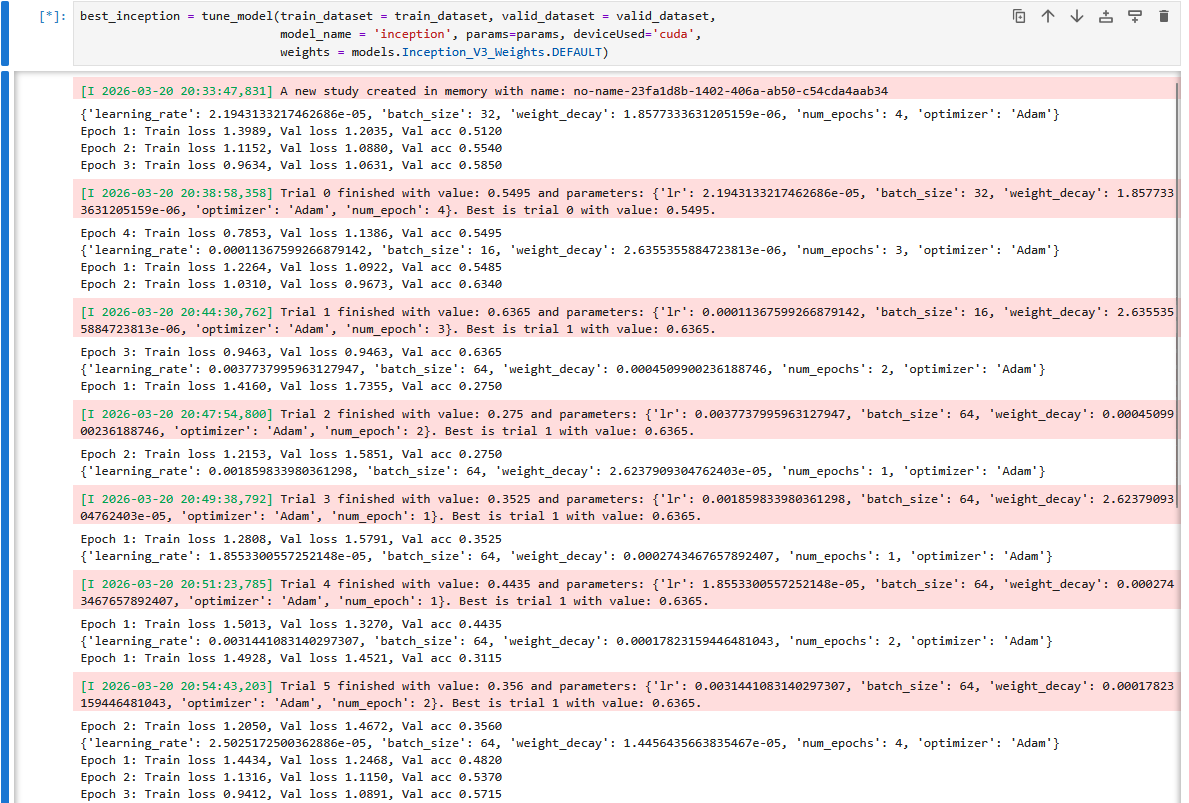

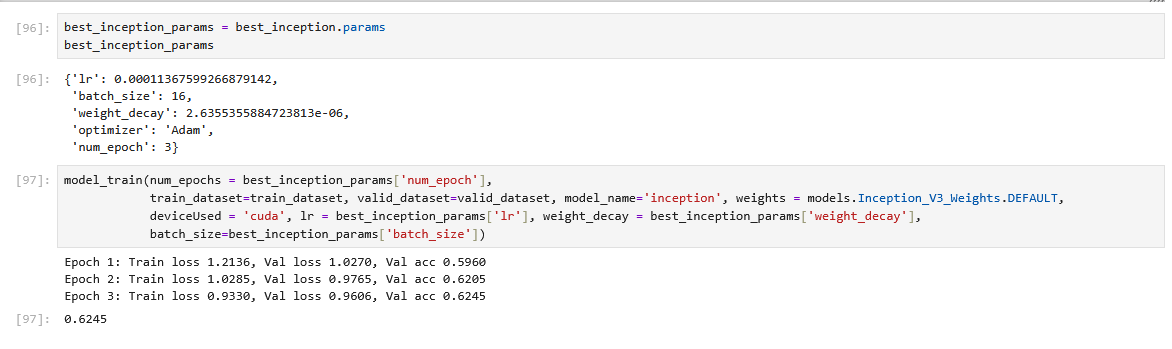

### Limitations
We were unable to test the models with a different optimizer, and cannot say how well they would perform if a different optimization algorithm were used.

We did not implement proper colour channels, and are unsure of what effect that would have on performance.

We were severely limited by processing power and memory, and could at max process 10,000 jets at a time. The full dataset contains over 800,000. Thus, we cannot say how well the models would perform with a very large dataset. We do know that the model performs poorly with a very small dataset (under 1,000 jets).

We did not run K-fold cross-validation or run our model on a test set after training. This may or may not have an effect on accuracy and performance. 

Our tuner seemed to have a bias towards earlier round and the accuracy began to taper off in later rounds.

When training the model we noticed that increasing the size of the dataset that the model was trained resulted in diminishing returns from the accuracy of the model  